#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [2]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [59]:
type(analysis_config)
analysis_config

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

#### Define dataset methods

In [4]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#make analysis folder 
hour_str = datetime.now().strftime("%H")

storage_folder_name = root_dir / Path(f"processed_{data_type_used}")
print(storage_folder_name)
storage_folder_name.mkdir(parents=True, exist_ok=True)


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [5]:
# ---------- Project specific hooks (unchanged stubs) ----------

def return_binary_activity_vec_sig_active_in_task_stage(dataset_object: DatasetObject) -> pd.DataFrame:
    raise NotImplementedError

In [6]:
def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES")
    print("="*70)

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")


In [7]:
#get all dataset names
#verify you are using the correct number of dataset 
source_dataset_location = Path(r"C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects")
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match expected"

Found 35 files in C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_obje

In [8]:
import h5py

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [9]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
print("\n" + "="*60)
print(f"SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
        
check_corrupted_files(failed_files)

Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 136 cells × 150415 frames
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 168 cells × 97940 frames
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 157 cells × 108794 frames
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 160 cells × 191533 frames
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 145 cells × 108651 frames
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 147 cells × 128277 frames
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 183 cells × 153831 frames
Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  13_4_WT_RS2: 171 cells × 106245 frames
Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  13_5_HET_RS1: 120 cells × 229350 frames
Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  13_5_HET_RS2: 125 cells × 141283 frames
Loading file 10/35: 13_5_HET_RS3_dataset_object.mat
  13_5_HET_RS3: 131 cel

<Axes: >

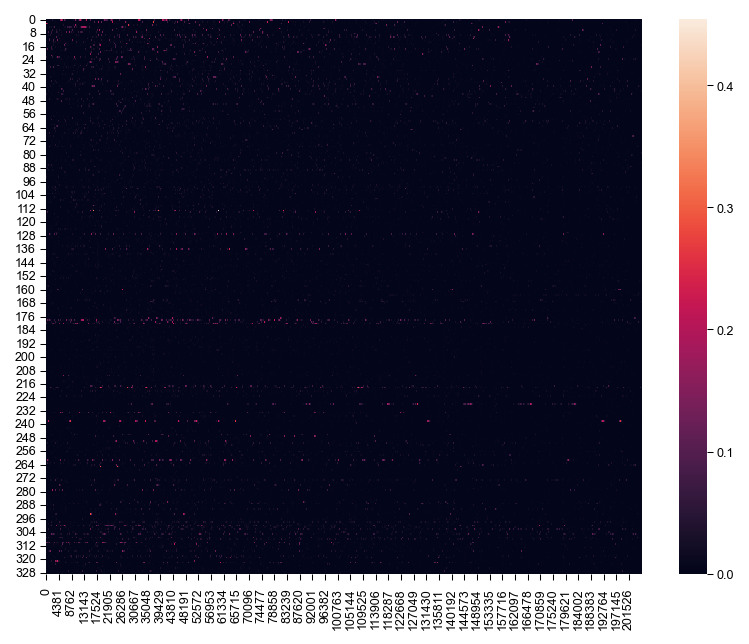

In [10]:
sns.heatmap(obj['temporal_weights'])

<Axes: >

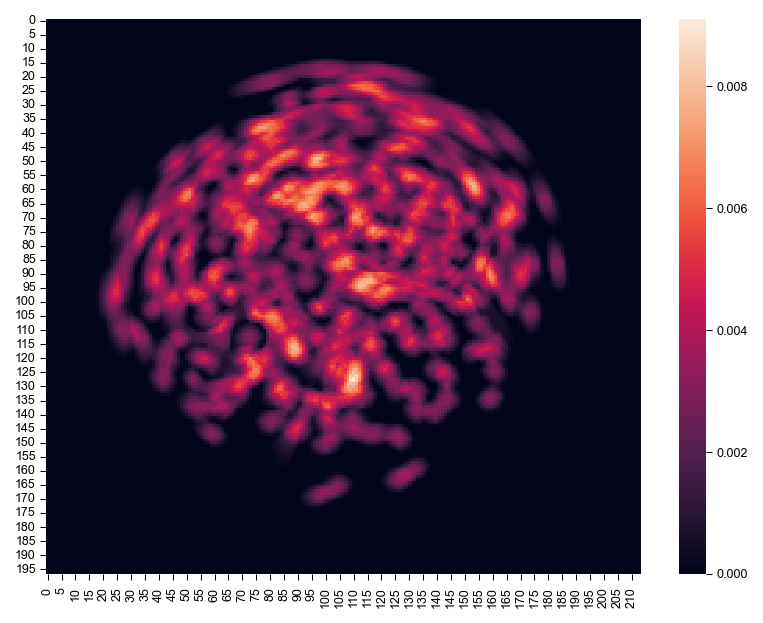

In [11]:
sns.heatmap(np.mean(obj['spatial_weights'], axis=0))

#### Create per subject tabular data

In [12]:
obj['labels']

array([[ 1.],
       [ 1.],
       [ 1.],
       ...,
       [15.],
       [15.],
       [15.]])

#### Run ensemble detection analysis

In [13]:
# import canonical ensemble matrix previously created in MATLAB, used for paper

#find old file- 
canonical_file = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")

#load canonical file
canonical_data = pd.read_parquet(canonical_file)

#inspect canonical file
print(canonical_data.info())
canonical_data.head(3)


<class 'pandas.core.frame.DataFrame'>
Int64Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.0,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.0,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.0,False


In [46]:
def dataset_obj_to_df(dataset_obj):
    # Create DataFrame from raster (cells × frames)
    print(f"\nProcessing {dataset_obj['name']}: {dataset_obj['raster'].nbytes} bytes")
    #setup dataset df 
    raster_df = pd.DataFrame(
        dataset_obj['raster'].T,
        index=[f'frame_{i}' for i in range(dataset_obj['raster'].shape[1])],
        columns = [f'cell_{i}' for i in range(dataset_obj['raster'].shape[0])],
        dtype = 'Sparse[int]')
            #add labels
    raster_df['labels'] = dataset_obj['labels']

    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    
    return raster_df

In [47]:
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0])
print(test_df.info())
test_df


Processing 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 140 entries, cell_0 to session
dtypes: Sparse[int32, 0](136), float64(1), object(3)
memory usage: 12.5+ MB
None


,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_130,cell_131,cell_132,cell_133,cell_134,cell_135,labels,subject_name,geno,session
frame_0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,10_3_HET_RS1,HET,RS1
frame_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,10_3_HET_RS1,HET,RS1
frame_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,10_3_HET_RS1,HET,RS1
frame_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,10_3_HET_RS1,HET,RS1
frame_4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,10_3_HET_RS1,HET,RS1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_150410,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150411,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150412,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150413,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1


In [48]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj)
    raster_dataframes[obj['name']] = raster_df

print(f"\nTotal DataFrames created: {len(raster_dataframes)}")


Processing 10_3_HET_RS1: 163651520 bytes

Processing 10_3_HET_RS2: 131631360 bytes

Processing 10_3_HET_RS3: 136645264 bytes

Processing 13_3_HET_RS1: 245162240 bytes

Processing 13_3_HET_RS2: 126035160 bytes

Processing 13_3_HET_RS3: 150853752 bytes

Processing 13_4_WT_RS1: 225208584 bytes

Processing 13_4_WT_RS2: 145343160 bytes

Processing 13_5_HET_RS1: 220176000 bytes

Processing 13_5_HET_RS2: 141283000 bytes

Processing 13_5_HET_RS3: 101650760 bytes

Processing 13_6_WT_RS1: 407216056 bytes

Processing 13_6_WT_RS2: 286371552 bytes

Processing 13_8_HET_RS1: 205506288 bytes

Processing 13_8_HET_RS2: 184071712 bytes

Processing 13_8_HET_RS3: 247363296 bytes

Processing 14_2_WT_RS1: 158077680 bytes

Processing 14_2_WT_RS2: 170570944 bytes

Processing 15_1_HET_RS1: 209435040 bytes

Processing 15_1_HET_RS2: 185898360 bytes

Processing 15_1_HET_RS3: 133253480 bytes

Processing 5_3_WT_RS1: 198030360 bytes

Processing 5_3_WT_RS2: 211466640 bytes

Processing 6_2_WT_RS1: 212864136 bytes

Pro

In [49]:
raster_dataframes[obj['name']]

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_209,cell_210,cell_211,cell_212,cell_213,cell_214,labels,subject_name,geno,session
frame_0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,9_3_HET_RS3,HET,RS3
frame_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,9_3_HET_RS3,HET,RS3
frame_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,9_3_HET_RS3,HET,RS3
frame_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,9_3_HET_RS3,HET,RS3
frame_4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,9_3_HET_RS3,HET,RS3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,9_3_HET_RS3,HET,RS3
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,9_3_HET_RS3,HET,RS3
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,9_3_HET_RS3,HET,RS3
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,9_3_HET_RS3,HET,RS3


In [ ]:
#extract ensemble cols
stage_cols = analysis_config.task_phase_names
print(f"extracting columns: {stage_cols}")
#get ensemble info from canon df
canonical_ensemble  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canonical_ensemble

extracting columns: ['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS']


,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
10_3_HET_RS1-1,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-101,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-104,HET,Het VEH,0.0,0.0,1.0,1.0,0.0,0.0
10_3_HET_RS1-107,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
9_3_HET_RS3-95,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-96,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0


<Axes: ylabel='unique_ID-geno-geno_day'>

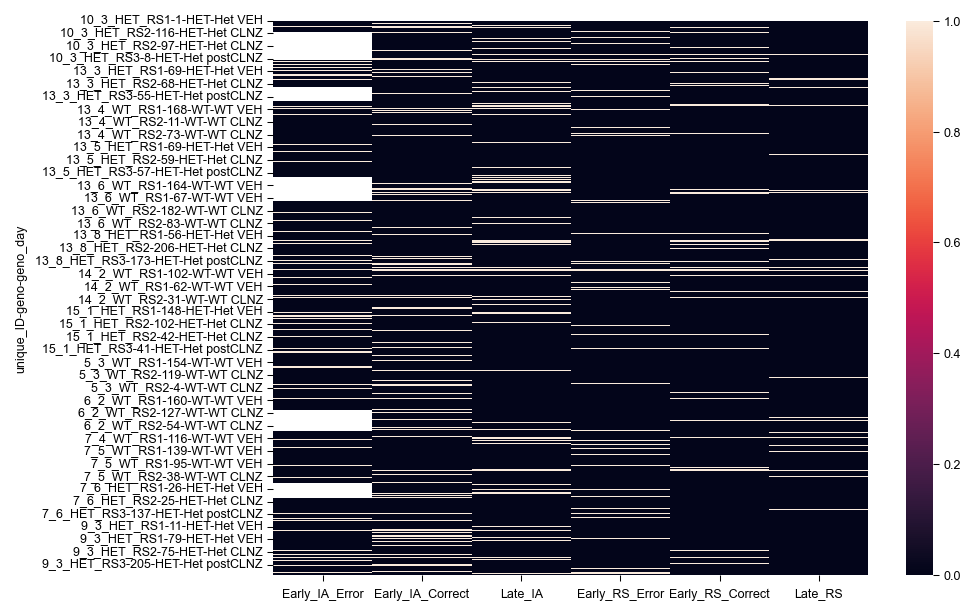

In [ ]:
sns.heatmap(canonical_ensemble.loc[:, stage_cols])

#### add task stage info

In [ ]:
# %% RS specific raster slicing: slice into sections (RS specific: pre post ITI)
sec_names = analysis_config.trial_section_names;


# %% create binned and sectioned raster
raster=  vectorize_raster_methods.slice_trim_raster(new_spikes, dataset_object.labels);
n_cells = size(raster.ITI{1},1);
binned_raster = timeseries_analysis_methods.bin_sectioned_raster(raster); #downsample to analysis_config bin size


In [ ]:

# %% get feature labels
phase_index_obj = phase_index(dataset_object.labels, time_series_options.phase_type_to_use); %extract criteria from options, creates new phase object
feature_vec_struct = struct(); %stores feature_vecs for easier use later
[feature_vec_struct.task_phase_vec, feature_vec_struct.IA_RS_vec, feature_vec_struct.corr_err_vec]= return_trial_feature_vecs(phase_index_obj);


In [65]:
def _coerce_labels(
    input_labels: Union[Dict[str, Sequence[bool]], Tuple[Sequence[bool], Sequence[bool]]]
) -> Tuple[np.ndarray, np.ndarray]:
    """Accept dict {'in_RS','is_error'} or tuple (in_RS,is_error)."""
    if isinstance(input_labels, dict):
        in_RS = np.asarray(input_labels["in_RS"], dtype=bool)
        is_error = np.asarray(input_labels["is_error"], dtype=bool)
    else:
        in_RS = np.asarray(input_labels[0], dtype=bool)
        is_error = np.asarray(input_labels[1], dtype=bool)
    assert in_RS.shape == is_error.shape and in_RS.ndim == 1
    return in_RS, is_error


def _canonical_keys(phase_names):
    # Map lowercase -> original key from your config
    canon = {name.lower(): name for name in phase_names}
    required = [
        "early_ia_error","early_ia_correct","late_ia",
        "early_rs_error","early_rs_correct","late_rs"
    ]
    missing = [r for r in required if r not in canon]
    if missing:
        raise KeyError(f"analysis_config.task_phase_names missing keys (case-insensitive): {missing}")
    return canon

In [ ]:
def build_phase_masks(input_labels: Union[Dict[str, Sequence[bool]], Tuple[Sequence[bool], Sequence[bool]]],analysis_config) -> Dict[str, np.ndarray]:
    """
    Build boolean masks for the 6 complex phases, writing the results into the
    exact keys provided in analysis_config['task_phase_names'] (case-insensitive matching).
    analysis_config needs:
      - 'task_phase_names': list/tuple of 6 names (any capitalization)
      - 'early_criteria_value': int
    """
    #check error inputs
    assert (~in_RS).any() and in_RS.any(), "Need at least one IA and one RS trial"
    assert analysis_config['early_criteria_value'] >= 1, "early_criteria_value must be >= 1"

    in_RS, is_error = _coerce_labels(input_labels)
    idx = np.arange(len(in_RS), dtype=int)
    T = len(idx)

    phase_names = analysis_config.task_phase_names
    earlyN = analysis_config.early_criteria_value
    canon = _canonical_keys(phase_names)  # lower -> original key

    ia_pos = np.where(~in_RS)[0]
    rs_pos = np.where(in_RS)[0]
    assert ia_pos.size > 0 and rs_pos.size > 0, "Must contain IA and RS trials"

    first_RS = rs_pos[0]
    last_IA = ia_pos[ia_pos <= first_RS][-1]
    last_RS = rs_pos[-1]

    early_IA_end = ia_pos[min(earlyN, ia_pos.size) - 1]
    early_RS_end = rs_pos[min(earlyN, rs_pos.size) - 1]

    in_early_IA = idx <= early_IA_end
    in_early_RS = in_RS & (idx <= early_RS_end)

    out = {name: np.zeros(T, dtype=bool) for name in phase_names}

    # Early IA error with fallback
    ia_err_early = is_error & (~in_RS) & in_early_IA
    if ia_err_early.any():
        out[canon["early_ia_error"]] = ia_err_early
    else:
        ia_err_idx = np.where(is_error & (~in_RS))[0]
        if ia_err_idx.size > 0:
            pick = ia_err_idx[:min(ia_err_idx.size, earlyN)]
            mask = np.zeros(T, dtype=bool)
            mask[pick] = True
            out[canon["early_ia_error"]] = mask

    # Early IA correct
    out[canon["early_ia_correct"]] = (~is_error) & (~in_RS) & in_early_IA

    # Late IA, not errors
    late_ia_start = last_IA - earlyN + 1
    late_ia_idx = np.arange(late_ia_start, last_IA + 1, dtype=int)
    mask_late_ia = np.zeros(T, dtype=bool)
    mask_late_ia[late_ia_idx] = True
    out[canon["late_ia"]] = mask_late_ia & (~is_error)

    # Early RS error with fallback
    rs_err_early = is_error & in_RS & in_early_RS
    if rs_err_early.any():
        out[canon["early_rs_error"]] = rs_err_early
    else:
        rs_err_idx = np.where(is_error & in_RS)[0]
        if rs_err_idx.size > 0:
            pick = rs_err_idx[:min(rs_err_idx.size, earlyN)]
            mask = np.zeros(T, dtype=bool)
            mask[pick] = True
            out[canon["early_rs_error"]] = mask

    # Early RS correct
    out[canon["early_rs_correct"]] = (~is_error) & in_RS & in_early_RS

    # Late RS, not errors
    late_rs_start = last_RS - earlyN + 1
    late_rs_idx = np.arange(late_rs_start, last_RS + 1, dtype=int)
    assert len(late_rs_idx) == earlyN
    mask_late_rs = np.zeros(T, dtype=bool)
    mask_late_rs[late_rs_idx] = True
    out[canon["late_rs"]] = mask_late_rs & (~is_error)

    # Reference indices
    out["_last_IA_index"] = int(last_IA)
    out["_last_RS_index"] = int(last_RS)
    out["_early_IA_end_index"] = int(early_IA_end)
    out["_early_RS_end_index"] = int(early_RS_end)
    return out

#### Test state detection

In [69]:
T = 20
in_RS = np.array([False]*10 + [True]*10)
is_error = np.zeros(T, dtype=bool)
is_error[[1,7,12,14]] = True
toy = {"in_RS": in_RS, "is_error": is_error}

def summarize(res: Dict[str, np.ndarray]) -> Dict[str, list]:
    out = {}
    for k, v in res.items():
        if isinstance(v, np.ndarray) and v.dtype == bool:
            out[k] = np.where(v)[0].tolist()
        else:
            out[k] = v
    return out

summary = summarize(build_phase_masks(toy, analysis_config))
for k, v in summary.items():
    print(f"{k}: {v}")
    

Early_IA_Error: [1]
Early_IA_Correct: [0, 2, 3, 4]
Late_IA: [5, 6, 8, 9]
Early_RS_Error: [12, 14]
Early_RS_Correct: [10, 11, 13]
Late_RS: [15, 16, 17, 18, 19]
_last_IA_index: 9
_last_RS_index: 19
_early_IA_end_index: 4
_early_RS_end_index: 14


#### Run activity enrichment analysis

In [ ]:
if run_activity_enrichment:
    def _job(name: str) -> pd.DataFrame:
        ds = dfm.get_dataset_object_i(dataset_folders / name, data_type_used)
        return return_binary_activity_vec_sig_active_in_task_stage(ds)

    tables: List[pd.DataFrame] = [None] * len(content_names)
    with ProcessPoolExecutor() as ex:
        futs = {ex.submit(_job, nm): i for i, nm in enumerate(content_names)}
        for fut in as_completed(futs):
            tables[futs[fut]] = fut.result()

    needed_cols = analysis_config.get_num_phase_pairs(phase_type) + 2
    fixed = []
    for df in tables:
        if df.shape[1] < needed_cols and "baseline" not in df.columns:
            df = df.copy()
            df["baseline"] = 0
        fixed.append(df)

    combined = pd.concat(fixed, axis=0, ignore_index=True)
    metadata_vec = [
        str(datetime.now()),
        analysis_config.num_shuffles,
        analysis_config.percentile,
        analysis_config.drop_low_value_peak_events,
        analysis_config.cutoff_filter,
        analysis_config.peak_event_cutoff_percentile,
    ]
    meta_df = pd.DataFrame([metadata_vec] * len(combined))
    combined = pd.concat([combined, meta_df], axis=1)

    dataset_cohort = "WT_CLNZ_" if use_WT_CLNZ_folder else "main_datasets_"
    out_name = f"{dataset_cohort}{phase_type}TACO- {data_type_used}_activity by task phase_{datetime.now().date()}.xlsx"
    combined.to_excel(out_name, index=False)

if export_mean_active:
    mean_tables: List[pd.DataFrame] = []
    for i, nm in enumerate(content_names, start=1):
        print(f"{i}/{len(content_names)} mean activity found")
        ds = dfm.get_dataset_object_i(dataset_folders / nm, data_type_used)
        curr_mean = ds.raster.mean(axis=1)
        names = np.full(curr_mean.shape[0], ds.name)
        mean_tables.append(pd.DataFrame({"curr_mean_active": curr_mean, "name_col": names}))

    activation_table = pd.concat(mean_tables, axis=0, ignore_index=True)
    out_name2 = f"{data_type_used}_mean dataset activity_{datetime.now().date()}.xlsx"
    activation_table.to_excel(out_name2, index=False)

print("Done creating all thresholded activity vectors for all datasets. Exported")


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.